## 📩 Email Data Preprocessing and Message Extraction

This notebook begins with processing a set of parsed email data shared by Brent West. According to Brent, this is an old archive (over 20 years old) from **Mike Brewer**, an engineer from Abbott Power Plant. These emails were shared in a structured format as `.eml` files, and the goal is to retain their original metadata (file paths, folder structure, and filenames), then extract and clean individual messages from email chains for further analysis and archiving.

---

### 🔹 Load the Parsed Email Data

We start by loading the previously parsed email metadata and content stored in a CSV file.


In [12]:
import os
import pandas as pd

df = pd.read_csv("C:\Emails_Archiving\emails_parsed.csv")

### 🔹 Extract Folder Structure from File Path
Each email file path contains useful metadata (such as the folder it was in and the original file name). We split the file path on backslashes \ to break this down into separate columns.

In [13]:
# 1) Split the 'file_path' column on backslashes (like before).
split_path_df = df["file_path"].str.split(r'\\', expand=True)

# 2) Rename the columns in the new DataFrame.
split_path_df.columns = [f"Folder_{i+1}" for i in range(split_path_df.shape[1])]

# 3) Join the split path columns back to the original DataFrame.
df = df.join(split_path_df)


In [14]:
df.head()

,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,Folder_7,Folder_8,Folder_9,Folder_10
0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030610-1444 Update on Beth-s work.eml,None,None
1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None
2,20030616-0821 Abbott Document - Information Ma...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Mike,\nWelcome back!!\n\nAttached is the Abbot...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030616-0821 Abbott Document - Information Ma...,None,None
3,20030618-0848 RE- Abbott Document - Informatio...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Mike,\nSuper!\n\nI am excited to be here -- th...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030618-0848 RE- Abbott Document - Informatio...,None,None
4,20030625-1320 Your login has been disabled by ...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"All,\n\nWhen you are logging in to InfoView, i...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030625-1320 Your login has been disabled by ...,None,None


### 🔹 Step 3: Extract Email Title (File Name without Extension)
Next, we extract the original email file name (without the .eml extension) and store it in a new column called email_title. This will help us keep track of the message context, even after we separate multi-part chains.

In [15]:
# Create a new column "email_title" by extracting the last part of the path
#    and removing the ".eml" extension. 
#    - os.path.basename() gives the final filename from the path.
#    - os.path.splitext() splits off the file extension.

def get_email_title(path):
    if not path:  # Handle empty or NaN paths
        return ""
    # Example: "20030610-1444 Update on Beth-s work.eml" -> ("20030610-1444 Update on Beth-s work", ".eml")
    base_name = os.path.basename(path)
    title_without_ext, _ = os.path.splitext(base_name)
    return title_without_ext

df["email_title"] = df["file_path"].apply(get_email_title)

df = df.reset_index()

# Now "email_title" should have the file name without the .eml extension,
# e.g. "20030610-1444 Update on Beth-s work"
df.head()

,index,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,Folder_7,Folder_8,Folder_9,Folder_10,email_title
0,0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030610-1444 Update on Beth-s work.eml,None,None,20030610-1444 Update on Beth-s work
1,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None,20030612-1350 RE- Abbott-s new IEPA requirements
2,2,20030616-0821 Abbott Document - Information Ma...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Mike,\nWelcome back!!\n\nAttached is the Abbot...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030616-0821 Abbott Document - Information Ma...,None,None,20030616-0821 Abbott Document - Information Ma...
3,3,20030618-0848 RE- Abbott Document - Informatio...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Mike,\nSuper!\n\nI am excited to be here -- th...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030618-0848 RE- Abbott Document - Informatio...,None,None,20030618-0848 RE- Abbott Document - Informatio...
4,4,20030625-1320 Your login has been disabled by ...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"All,\n\nWhen you are logging in to InfoView, i...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030625-1320 Your login has been disabled by ...,None,None,20030625-1320 Your login has been disabled by ...


### ✅ Optional Save to CSV

In [18]:
# #(Optional) Save to CSV:
# df.to_csv("C:\Emails_Archiving\updated_data_with_split_paths.csv", index=False)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 19-20: truncated \uXXXX escape (4211045593.py, line 2)

### 📬 Break Email Chains into Individual Messages
Many email files are long threads with multiple forwarded or replied messages inside. To preserve each part of the conversation, we split messages based on the delimiter:

    -----Original Message-----


This delimiter usually marks the start of a new message within an email thread.

In [19]:

import pandas as pd

# Example: Assuming df is your DataFrame with an 'email_text' column.
# For instance:
# df = pd.read_csv("C:\Emails_Archiving\updated_data_with_split_paths.csv")

# 1. Create a new column that contains a list of individual messages by splitting on the delimiter.
df["email_original_message"] = df["email_text"].str.split("-----Original Message-----")

# 2. Explode the DataFrame so that each message in the list becomes its own row.
df_exploded = df.explode("email_original_message").reset_index(drop=True)

# 3. (Optional) Remove any extra leading/trailing whitespace from the individual messages.
df_exploded["email_original_message"] = df_exploded["email_original_message"].str.strip()

# Now, df_exploded contains all original columns (including the full 'email_text') 
# and the additional 'email_original_message' column, with one row per individual message.

df_exploded.head()

,index,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,Folder_7,Folder_8,Folder_9,Folder_10,email_title,email_original_message
0,0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030610-1444 Update on Beth-s work.eml,None,None,20030610-1444 Update on Beth-s work,"Hi all,\nThe Document & Information Management..."
1,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None,20030612-1350 RE- Abbott-s new IEPA requirements,Nope. By CC all Abbott management staff is aw...
2,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None,20030612-1350 RE- Abbott-s new IEPA requirements,"From: \tLeitz, Beth N (PC&M) \nSent:\tWedne..."
3,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None,20030612-1350 RE- Abbott-s new IEPA requirements,"From:\tDelgado, Sylvia M. (Facilities and Serv..."
4,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,20030612-1350 RE- Abbott-s new IEPA requiremen...,None,None,20030612-1350 RE- Abbott-s new IEPA requirements,"From: \tLeitz, Beth N (PC&M) \nSent:\tWedne..."


## 📥 Extracting Email Header Information

This section extracts structured metadata (like sender, recipient, subject, etc.) from each individual email message using regular expressions.

1. **Import Libraries**  
   Imports the `re` and `pandas` libraries for regex parsing and DataFrame handling.

2. **Define `extract_headers()` Function**  
   This function attempts to parse email headers from the start of a message string. It uses a regular expression pattern to extract:
   - `From`
   - `Sent`
   - `To`
   - `Cc` (optional)
   - `Subject`
   - `Importance` (optional)  
   It separates these header values from the message body, storing the remainder as `email_text_content`.

3. **Apply Header Extraction to Messages**  
   Applies the `extract_headers()` function to each row in the `email_original_message` column of the `df_exploded` DataFrame. This creates a Series of dictionaries with parsed header fields.

4. **Convert Header Dictionaries to DataFrame**  
   Converts the Series of dictionaries into a new DataFrame (`header_df`), where each key becomes a column.

5. **Merge with Original Data**  
   Concatenates the new header fields with the original exploded DataFrame so that each message now includes structured fields like `from_email`, `to_email`, `subject_email`, etc., as well as the cleaned message body.

6. **Save the Final Output**  
   Saves the enriched `df_exploded` DataFrame (with parsed header fields and message content) to a new CSV file for downstream use.


In [20]:
import re
import pandas as pd

def extract_headers(message):
    # Ensure the message is a string.
    if not isinstance(message, str):
        message = ""
    
    # Regex pattern that looks for a header block at the very beginning.
    # It expects headers in the following order:
    # From, Sent, To, optional Cc, Subject, optional Importance, then a blank line.
    header_pattern = (
        r"^From:\s*(?P<from_email>.*?)\r?\n"
        r"Sent:\s*(?P<sent_email>.*?)\r?\n"
        r"To:\s*(?P<to_email>.*?)\r?\n"
        r"(?:Cc:\s*(?P<cc_email>.*?)\r?\n)?"         # Optional Cc line
        r"Subject:\s*(?P<subject_email>.*?)\r?\n"
        r"(?:Importance:\s*(?P<importance_email>.*?)\r?\n)?"  # Optional Importance line
        r"\r?\n"  # Blank line indicating the end of the header block.
    )
    m = re.search(header_pattern, message, re.DOTALL)
    if m:
        headers = m.groupdict()
        # Remove the header block from the message.
        email_text_content = message[m.end():].lstrip()
        headers["email_text_content"] = email_text_content
        return headers
    else:
        # If no header block is found, return None for header fields,
        # and leave the original message as email_text_content.
        return {
            "from_email": None,
            "sent_email": None,
            "to_email": None,
            "cc_email": None,
            "subject_email": None,
            "importance_email": None,
            "email_text_content": message
        }

# --- Assuming you already have a DataFrame (df_exploded) from previous steps,
# where df_exploded has a column "email_original_message" containing each individual message.

# Apply the header extraction function to each message.
header_data = df_exploded["email_original_message"].apply(extract_headers)

# Convert the resulting series of dictionaries into a DataFrame.
header_df = header_data.apply(pd.Series)

# Concatenate the new header columns with the original exploded DataFrame.
df_exploded = pd.concat([df_exploded, header_df], axis=1)

# Now, the DataFrame contains the following new columns (if headers were present):
#   - from_email
#   - sent_email
#   - to_email
#   - cc_email (optional)
#   - subject_email
#   - importance_email (optional)
#   - email_text_content (the message with the header block removed)


# -----Save the Final Output-----

# print(df_exploded.head())

# df_exploded.to_csv(r"C:\Emails_Archiving\emails_parsed_exploded.csv")

In [22]:
import pandas as pd
df_exploded = pd.read_csv(r"C:\Emails_Archiving\emails_parsed_exploded.csv")
df_exploded = df_exploded.drop(columns=['Unnamed: 0', 'level_0', 'index'], errors='ignore')

df_exploded

C:\Users\terbe\AppData\Local\Temp\ipykernel_31900\415509580.py:2: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_exploded = pd.read_csv(r"C:\Emails_Archiving\emails_parsed_exploded.csv")


,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,Folder_7,...,Folder_10,email_title,email_original_message,from_email,sent_email,to_email,cc_email,subject_email,importance_email,email_text_content
0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,...,NaN,20030610-1444 Update on Beth-s work,"Hi all,\nThe Document & Information Management...",NaN,NaN,NaN,NaN,NaN,NaN,"Hi all,\nThe Document & Information Management..."
1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,...,NaN,20030612-1350 RE- Abbott-s new IEPA requirements,Nope. By CC all Abbott management staff is aw...,NaN,NaN,NaN,NaN,NaN,NaN,Nope. By CC all Abbott management staff is aw...
2,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,...,NaN,20030612-1350 RE- Abbott-s new IEPA requirements,"From: \tLeitz, Beth N (PC&M) \nSent:\tWedne...","Leitz, Beth N (PC&M)","Wednesday, June 11, 2003 1:42 PM","Rundus, Richard (Rick) E (PC&M)",NaN,FW: Abbott's new IEPA requirements,NaN,"Rick,\nBelow is Sylvia's response to my reques..."
3,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,...,NaN,20030612-1350 RE- Abbott-s new IEPA requirements,"From:\tDelgado, Sylvia M. (Facilities and Serv...","Delgado, Sylvia M. (Facilities and Services)","Wednesday, June 11, 2003 1:25 PM","Leitz, Beth N (PC&M)",NaN,RE: Abbott's new IEPA requirements,NaN,Sounds good! Glad you can support APP in this ...
4,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,APP- Admin- Archivist,...,NaN,20030612-1350 RE- Abbott-s new IEPA requirements,"From: \tLeitz, Beth N (PC&M) \nSent:\tWedne...","Leitz, Beth N (PC&M)","Wednesday, June 11, 2003 1:21 PM","Delgado, Sylvia M. (Facilities and Services)",NaN,Abbott's new IEPA requirements,NaN,"Hi Sylvia,\n\nI am with UIUC Archives, working..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79671,20000110-1656 RE- Steam load profiles. CWP Act...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"The IPC is in excel files, and is 15 minute da...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,repaired.pst,01 Repaired Folder,Top of Personal Folders,Inbox,...,20000110-1656 RE- Steam load profiles. CWP Act...,20000110-1656 RE- Steam load profiles. CWP Act...,"The IPC is in excel files, and is 15 minute data.",NaN,NaN,NaN,NaN,NaN,NaN,"The IPC is in excel files, and is 15 minute data."
79672,20000110-1656 RE- Steam load profiles. CWP Act...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"The IPC is in excel files, and is 15 minute da...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,repaired.pst,01 Repaired Folder,Top of Personal Folders,Inbox,...,20000110-1656 RE- Steam load profiles. CWP Act...,20000110-1656 RE- Steam load profiles. CWP Act...,"From:\tErickson, Keith R (O&M) \nSent:\tMonday...","Erickson, Keith R (O&M)","Monday, January 10, 2000 5:02 PM","Brewer, Michael K (O&M)","Dancey, Dan C (O&M)",RE: Steam load profiles. CWP Acti

## 🧾 Viewing Extracted Email Data

This section demonstrates how we can view both the original email message and the structured header fields we extracted earlier.

- First, we display the full original message content from a specific row (in this case, row 18).
- Then, we show the individual header fields that were parsed from the message, including:
  - **From**
  - **Sent**
  - **To**
  - **Cc**
  - **Subject**
  - **Importance**

This helps us verify that the header extraction process is working correctly and that we're able to isolate useful metadata for each individual email.


In [8]:
# Print the original email content
print("Original Email:\n")
print(df_exploded["email_original_message"][18])
print("\n")

# Print the extracted header fields in a clean format
print("Extracted Header Contents:\n")
print("From: " + str(df_exploded["from_email"][18]))
print("Sent: " + str(df_exploded["sent_email"][18]))
print("To: " + str(df_exploded["to_email"][18]))
print("Cc: " + str(df_exploded["cc_email"][18]))
print("Subject: " + str(df_exploded["subject_email"][18]))
print("Importance: " + str(df_exploded["importance_email"][18]))


Original Email:

From: 	Brewer, Michael K (PC&M)  
Sent:	Wednesday, July 02, 2003 9:34 AM
To:	Leitz, Beth   N (PC&M); Rogers, Jeff L (PC&M)
Cc:	PCandM:Computer Group
Subject:	RE: Adding Access to the G drive, avoid group logins.
Importance:	High

I want to discourage group logins such as APPELS, APPITS and mechanics.  Eventually they will be disabled as there is not personal accountabilty for network activity.  It can get us all in trouble.


Extracted Header Contents:

From: Brewer, Michael K (PC&M)  
Sent: Wednesday, July 02, 2003 9:34 AM
To: Leitz, Beth   N (PC&M); Rogers, Jeff L (PC&M)
Cc: PCandM:Computer Group
Subject: RE: Adding Access to the G drive, avoid group logins.
Importance: High


# Ideas for Extracted Features 

## 🔍 Searching for Emails Sent by a Specific Person

We can now search and filter emails based on the sender using fuzzy matching. This allows us to identify messages sent by a specific person, even if the name is slightly misspelled or formatted differently.

For example, to find all emails sent by **"Leitz, Beth"**, we use fuzzy string matching on the `from_email` field. This approach ensures that we catch variations like `"Beth Leitz <bleitz@domain.com>"`, `"Leitz, Beth A."`, or similar.

This is especially useful in older email archives where formatting might be inconsistent.


In [26]:
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

# Set the name you're trying to match
target_name = "Leitz, Beth"

# Set a similarity threshold (e.g., 80 or higher)
threshold = 80

# Create a boolean mask based on fuzzy matching
matches = df_exploded["from_email"].apply(
    lambda x: fuzz.partial_ratio(str(x).lower(), target_name.lower()) >= threshold
)

# Filter the DataFrame
leitz_beth_emails = df_exploded[matches]

# Preview
leitz_beth_emails[["from_email", "email_text_content"]]


,from_email,email_text_content
2,"Leitz, Beth N (PC&M)","Rick,\nBelow is Sylvia's response to my reques..."
4,"Leitz, Beth N (PC&M)","Hi Sylvia,\n\nI am with UIUC Archives, working..."
8,"Leitz, Beth N (PC&M)","Mike,\nWelcome back!!\n\nAttached is the Abbot..."
13,"Leitz, Beth N (PC&M)","Hi all,\nAfter further discussion with the Arc..."
15,"Leitz, Beth N (PC&M)","Mike,\nI think the best place to put the new t..."
...,...,...
69479,"Leitz, Beth N (PC&M)","Hello all,\nThese answers are from Lee regardi..."
69481,"Leitz, Beth N (PC&M)","Lee,\nTwo questions were brought up at our pla..."
69484,"Leitz, Beth N (PC&M)","Lee,\nTwo questions were brought up at our pla..."
69549,"Leitz, Beth N (PC&M)","Lee and John,\nThis version (named revision 1)..."


In [27]:
print("The total count from Beth Leitz Emails are, " + str(len(leitz_beth_emails)))

The total count from Beth Leitz Emails are, 386


## 📊 Summary: Analyzing Email Volume Over Time

In this section, we performed a temporal analysis of email activity based on the `sent_email` field:

1. **Datetime Conversion**  
   Converted the `sent_email` column from string format to datetime using `pd.to_datetime`, enabling robust time-based filtering and grouping.

2. **Filtering for a Specific Time Period**  
   Isolated emails sent in **July 2003** to support focused historical analysis.

3. **Grouping by Month and Year**  
   Created a new `year_month` column to aggregate email counts by month and year using `.dt.to_period("M")`.

4. **Email Volume Summary Table**  
   Counted the number of emails sent each month and displayed the results in a clean, tabular format.

5. **Visualization**  
   Plotted a horizontal bar chart showing the number of emails sent per month, allowing for easy visual comparison of email volume trends over time.


In [36]:
import warnings

# Suppress warnings (e.g., SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# Convert the 'sent_email' column to datetime format
df_exploded["sent_email_parsed"] = pd.to_datetime(df_exploded["sent_email"], errors="coerce")

# Filter rows where the email was sent in July 2003
emails_july_2003 = df_exploded[
    (df_exploded["sent_email_parsed"].dt.year == 2003) &
    (df_exploded["sent_email_parsed"].dt.month == 7)
]

print(" ")
print("The number of emails in the month of July, in the year 2003 was this many, " + str(len(emails_july_2003)))
print(" ")

 
The number of emails in the month of July, in the year 2003 was this many, 1392
 


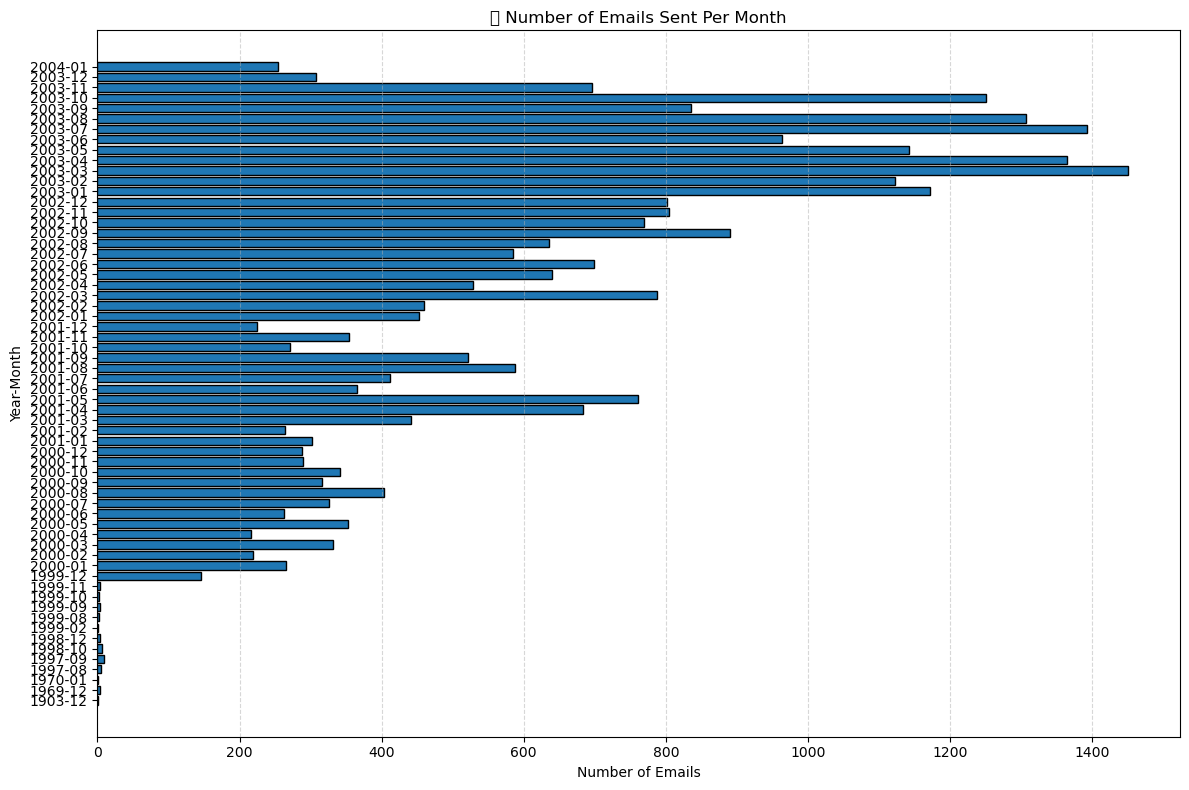

In [37]:
import warnings

# Suppress warnings (e.g., SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# Create a column for Year-Month
df_exploded["year_month"] = df_exploded["sent_email_parsed"].dt.to_period("M")

# Count the number of emails sent each month/year
monthly_counts = df_exploded["year_month"].value_counts().sort_index()

# Convert to DataFrame for readability
monthly_counts_df = monthly_counts.reset_index()
monthly_counts_df.columns = ["Year_Month", "Email_Count"]

import matplotlib.pyplot as plt

# Create a horizontal bar graph
plt.figure(figsize=(12, 8))
plt.barh(monthly_counts_df["Year_Month"].astype(str), monthly_counts_df["Email_Count"], edgecolor='black')

plt.xlabel("Number of Emails")
plt.ylabel("Year-Month")
plt.title("📬 Number of Emails Sent Per Month")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


### 📧 Summary: Analyzing Emails from Leitz, Beth Over Time
This analysis identifies and visualizes emails sent by "Leitz, Beth" using fuzzy string matching on sender names. After isolating relevant emails, we convert the sent date into a datetime format and group the messages by month and year. The final output is a time-series bar chart showing how frequently emails were sent by this individual over time. This method is useful for identifying patterns in communication frequency or spotting periods of high activity from specific senders.

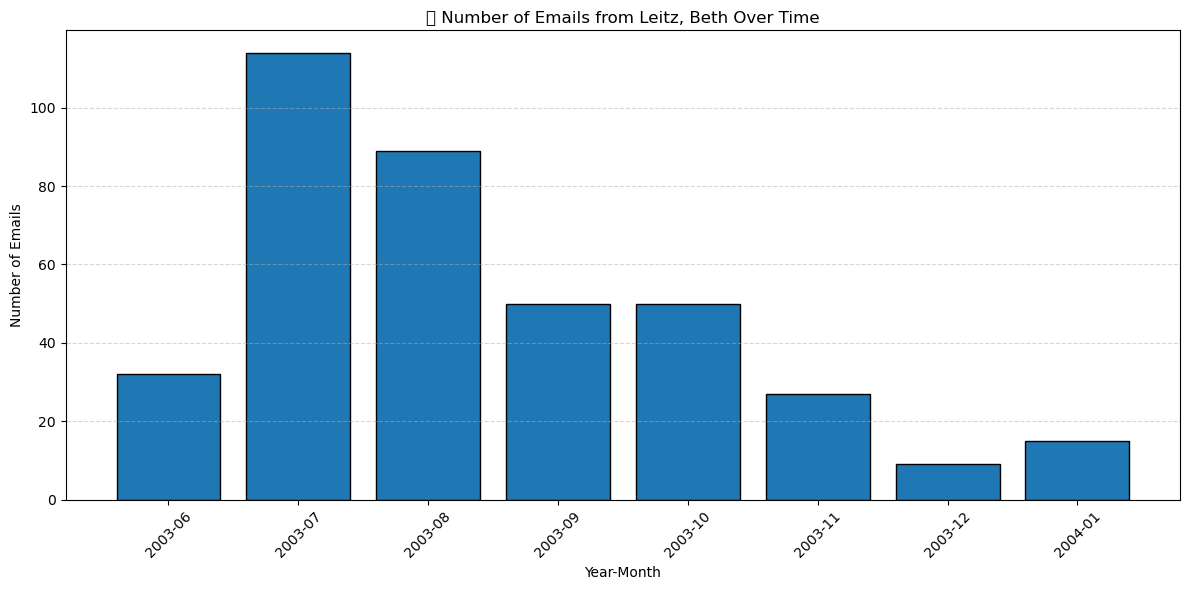

In [32]:
from fuzzywuzzy import fuzz
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Suppress warnings (e.g., SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# 1. Filter emails from "Leitz, Beth" using fuzzy matching
target_name = "Leitz, Beth"
threshold = 80

matches = df_exploded["from_email"].apply(
    lambda x: fuzz.partial_ratio(str(x).lower(), target_name.lower()) >= threshold
)
leitz_beth_emails = df_exploded[matches]

# 2. Convert 'sent_email' to datetime
leitz_beth_emails["sent_email_parsed"] = pd.to_datetime(leitz_beth_emails["sent_email"], errors="coerce")

# 3. Extract Year-Month for grouping
leitz_beth_emails["year_month"] = leitz_beth_emails["sent_email_parsed"].dt.to_period("M")

# 4. Count emails per month
leitz_monthly_counts = leitz_beth_emails["year_month"].value_counts().sort_index()
leitz_monthly_counts_df = leitz_monthly_counts.reset_index()
leitz_monthly_counts_df.columns = ["Year_Month", "Email_Count"]

# 5. Plot results
plt.figure(figsize=(12, 6))
plt.bar(leitz_monthly_counts_df["Year_Month"].astype(str), leitz_monthly_counts_df["Email_Count"], edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Number of Emails")
plt.title("📧 Number of Emails from Leitz, Beth Over Time")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Simple Topic Modeling with Bar Chart Visualization

This code analyzes the subject lines from emails to discover the main themes or topics being discussed. Here's what it does:

1. **Cleans the Subject Lines**  
   It removes punctuation, numbers, and common filler words (like "the", "and", etc.) to focus on meaningful content.

2. **Identifies Common Topics**  
   Using topic modeling (LDA), it groups the email subjects into a few distinct topics based on the words they contain.

3. **Assigns Each Subject a Topic**  
   Each email subject is labeled with its most likely topic.

4. **Visualizes the Results**  
   A bar chart is generated showing how many emails fall under each topic, giving us a simple overview of the most frequent themes in the dataset.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\terbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


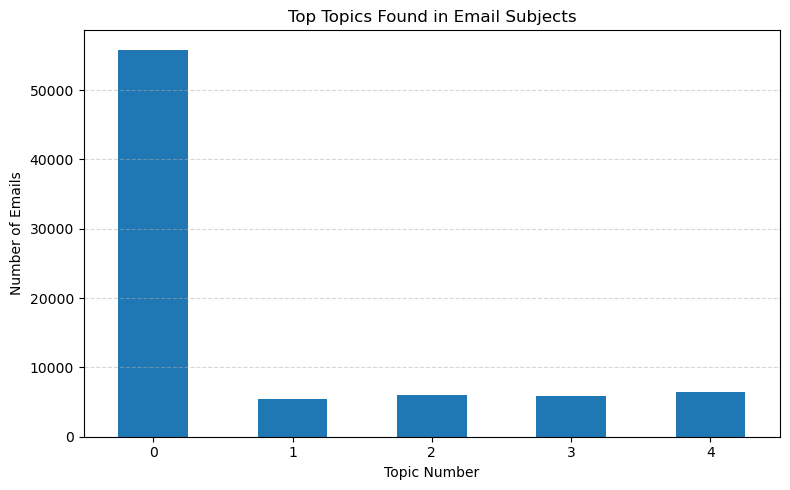

Topic #0: abbott, fw, power, plant, project, question, gas, line, hall, procure
Topic #1: fw, work, abbott, order, app, data, problems, uiuc, expansion, memtek
Topic #2: steam, gas, plant, fw, info, maintenance, visit, controls, tunnel, service
Topic #3: boiler, fw, report, fuel, meeting, oil, gas, bid, change, plan
Topic #4: fw, ok, rdm, boiler, water, xa, po, outage, status, notification


In [39]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
import warnings

# Suppress warnings (e.g., SettingWithCopyWarning)
warnings.filterwarnings("ignore")

nltk.download("stopwords")

# Simple cleaning function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

stop_words = set(stopwords.words("english"))

# Clean subject lines
df_exploded["subject_clean"] = df_exploded["subject_email"].apply(clean_text)
df_exploded["subject_clean"] = df_exploded["subject_clean"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

# Vectorize
vectorizer = CountVectorizer(max_df=0.9, min_df=2, stop_words="english")
doc_term_matrix = vectorizer.fit_transform(df_exploded["subject_clean"])

# Topic modeling
num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_topics = lda_model.fit_transform(doc_term_matrix)

# Assign topic to each row
df_exploded["dominant_topic"] = np.argmax(lda_topics, axis=1)

# Count the number of rows per topic
topic_counts = df_exploded["dominant_topic"].value_counts().sort_index()

# Plot as bar chart
plt.figure(figsize=(8, 5))
topic_counts.plot(kind="bar")
plt.title("Top Topics Found in Email Subjects")
plt.xlabel("Topic Number")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Function to display top keywords for each topic
def display_topics(model, feature_names, top_n=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features_indices = topic.argsort()[-top_n:][::-1]
        top_features = [feature_names[i] for i in top_features_indices]
        print(f"Topic #{topic_idx}: {', '.join(top_features)}")

# Get feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Display top keywords per topic
display_topics(lda_model, feature_names, top_n=10)



## 🧠 Topic Modeling with LDA and Llama 3.2
In this analysis, we performed unsupervised topic modeling on email subject lines using Latent Dirichlet Allocation (LDA). The process involved several key steps:

Preprocessing the email subjects by cleaning the text and removing stopwords.

Vectorizing the cleaned text using a bag-of-words model (CountVectorizer).

Applying LDA to uncover hidden topics within the email subjects.

Extracting the top 10 keywords for each topic.

While LDA is effective at clustering similar documents, the resulting keywords for each topic are often ambiguous or difficult to interpret, especially for end-users unfamiliar with the data.

To improve clarity, we used the Llama 3.2 language model via Ollama to generate natural language titles for each topic. We passed the top keywords from each topic into Llama with a prompt asking it to infer a short, descriptive title.

This approach helped convert abstract keyword clusters into intuitive, human-readable topic labels, improving the overall usability and interpretability of the topic modeling results.

In [43]:
# Path to Ollama and Llama model
ollama_path = r"C:\Users\terbe\AppData\Local\Programs\Ollama\ollama.exe"
model_name = "llama3.2"

# Function to generate topic title from keywords using Llama 3.2
def generate_topic_title(keywords):
    prompt = f"""
You are an expert at topic modeling and naming. Based on the following list of keywords extracted from a topic model, provide a short, clear, and descriptive title for the topic. Do not include any explanations—just return the title.

Keywords: {', '.join(keywords)}
"""
    try:
        result = subprocess.run(
            [ollama_path, "run", model_name, "--", prompt],
            input=prompt,
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace"
        )
        if result.returncode != 0:
            print("Error generating topic title:", result.stderr)
            return ""
        return result.stdout.strip()
    except Exception as e:
        print(f"An error occurred during topic title generation: {e}")
        return ""


In [42]:
import subprocess  
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")


# Get feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Store topics and generated titles
topic_titles = {}

# Loop through each topic and send to Llama for title generation
for topic_idx, topic in enumerate(lda_model.components_):
    top_features_indices = topic.argsort()[-10:][::-1]
    top_keywords = [feature_names[i] for i in top_features_indices]
    topic_title = generate_topic_title(top_keywords)
    topic_titles[topic_idx] = {
        "keywords": top_keywords,
        "generated_title": topic_title
    }
    print(f"Topic #{topic_idx} → Title: {topic_title}")


Topic #0 → Title: "ABBOTT Power Plant Procurement Project"
Topic #1 → Title: "UIUC IT Project Management Best Practices"
Topic #2 → Title: Steam Plant Operations or Control Systems
Topic #3 → Title: "Energy Contract Negotiation Strategies"
Topic #4 → Title: Boiler Water System Notification Outage Response.


In [44]:
for idx, info in topic_titles.items():
    print(f"\n🧠 Topic #{idx}: {info['generated_title']}")
    print("Keywords:", ", ".join(info["keywords"]))



🧠 Topic #0: "ABBOTT Power Plant Procurement Project"
Keywords: abbott, fw, power, plant, project, question, gas, line, hall, procure

🧠 Topic #1: "UIUC IT Project Management Best Practices"
Keywords: fw, work, abbott, order, app, data, problems, uiuc, expansion, memtek

🧠 Topic #2: Steam Plant Operations or Control Systems
Keywords: steam, gas, plant, fw, info, maintenance, visit, controls, tunnel, service

🧠 Topic #3: "Energy Contract Negotiation Strategies"
Keywords: boiler, fw, report, fuel, meeting, oil, gas, bid, change, plan

🧠 Topic #4: Boiler Water System Notification Outage Response.
Keywords: fw, ok, rdm, boiler, water, xa, po, outage, status, notification


In [47]:
# Print and collect data
topic_records = []

for idx, info in topic_titles.items():
    title = info['generated_title']
    keywords = ", ".join(info["keywords"])
    
    topic_records.append({
        "Topic Number": idx,
        "Llama Title": title,
        "Top Keywords": keywords
    })

# Convert to DataFrame
topic_titles_df = pd.DataFrame(topic_records)

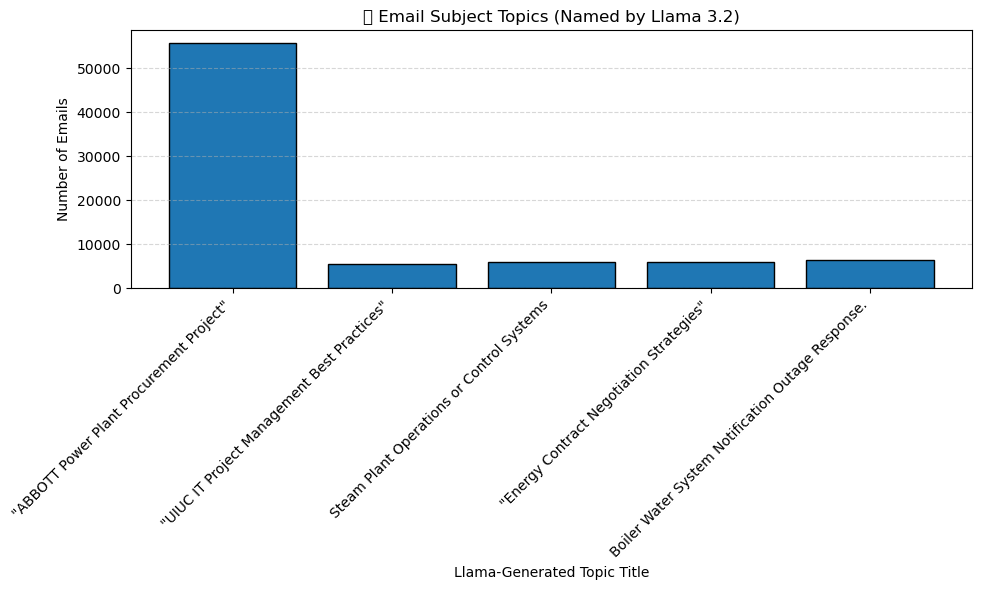

In [48]:
# Count the number of rows per topic (same as before)
topic_counts = df_exploded["dominant_topic"].value_counts().sort_index()

# Convert to DataFrame for labeling
topic_counts_df = topic_counts.reset_index()
topic_counts_df.columns = ["Topic", "Email_Count"]

# Replace topic numbers with Llama-generated titles
topic_counts_df["Topic_Label"] = topic_counts_df["Topic"].apply(
    lambda x: topic_titles.get(x, {}).get("generated_title", f"Topic #{x}")
)

# Plot as bar chart with new labels
plt.figure(figsize=(10, 6))
plt.bar(topic_counts_df["Topic_Label"], topic_counts_df["Email_Count"], edgecolor='black')
plt.title("📬 Email Subject Topics (Named by Llama 3.2)")
plt.xlabel("Llama-Generated Topic Title")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------------------------------------------

## 🔐 Overview: Using `presidio_analyzer` for PII Detection

The `presidio-analyzer` library, developed by Microsoft, is a powerful Python tool for **detecting, analyzing, and classifying Personally Identifiable Information (PII)** in unstructured text.

For more information please see the documentation here: https://microsoft.github.io/presidio/analyzer/

### 📦 What is `AnalyzerEngine`?

The core component of `presidio-analyzer` is the `AnalyzerEngine`. It scans text for sensitive information and labels it using structured entity types such as names, phone numbers, dates, and more.

```python
from presidio_analyzer import AnalyzerEngine


### 1. Analyze Sample Text for PII (Name + Phone Number)

In [51]:
from presidio_analyzer import AnalyzerEngine

analyzer = AnalyzerEngine()

text = "My name is John Doe and my number is 312-555-1234. I was born on 01/01/1990."
results = analyzer.analyze(text=text, language="en")

for result in results:
    print(result)


type: UK_NHS, start: 37, end: 49, score: 1.0
type: PERSON, start: 11, end: 19, score: 0.85
type: DATE_TIME, start: 65, end: 75, score: 0.85
type: PHONE_NUMBER, start: 37, end: 49, score: 0.75


In [53]:
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

anonymizer = AnonymizerEngine()

# Use OperatorConfig for redaction
operators = {
    "DEFAULT": OperatorConfig("redact")
}

# Perform anonymization
anonymized_result = anonymizer.anonymize(
    text=text,
    analyzer_results=results,
    operators=operators
)

print(anonymized_result.text)


My name is  and my number is . I was born on .


### 2. Anonymize: Replace Detected PII with Placeholders

In [54]:
from presidio_anonymizer import AnonymizerEngine

anonymizer = AnonymizerEngine()

anonymized_result = anonymizer.anonymize(text=text, analyzer_results=results)
print(anonymized_result.text)


My name is <PERSON> and my number is <UK_NHS>. I was born on <DATE_TIME>.


### 3. Anonymize with Redaction (Blackout Style)

In [58]:
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
import re

# Initialize engines
analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

# Sample text
text = "My name is John Doe and my number is 312-555-1234. I was born on 01/01/1990."

# Analyze for PII
results = analyzer.analyze(text=text, language="en")

# Instead of using redact, we will use a custom function to overlay black boxes
def custom_blackout(text, results):
    redacted_text = text
    offset = 0
    for result in sorted(results, key=lambda x: x.start):
        start, end = result.start + offset, result.end + offset
        length = end - start
        blackout = "█" * length
        redacted_text = redacted_text[:start] + blackout + redacted_text[end:]
        offset += len(blackout) - length
    return redacted_text

# Print redacted output with black boxes
print(custom_blackout(text, results))


My name is ████████ and my number is ████████████. I was born on ██████████.


### 4. Masking Example: Show Only Last 4 Digits of Phone Number

In [63]:
import re
from presidio_analyzer import AnalyzerEngine

# Sample input
text = "My name is John and my number is 312-555-1234."

# Initialize analyzer
analyzer = AnalyzerEngine()
results = analyzer.analyze(text=text, language="en")

def custom_mask_phone(text, results):
    new_text = text
    offset = 0

    for r in results:
        if r.entity_type == "PHONE_NUMBER":
            original = text[r.start:r.end]
            digits_only = re.sub(r'\D', '', original)

            if len(digits_only) <= 4:
                continue  # Skip if not enough digits to mask

            # Create the masked version
            masked_digits = "*" * (len(digits_only) - 4) + digits_only[-4:]

            # Now rebuild the original with formatting but replaced digits
            masked_iter = iter(masked_digits)
            formatted_masked = ''.join(
                next(masked_iter) if c.isdigit() else c for c in original
            )

            # Replace the original substring with the formatted masked version
            start = r.start + offset
            end = r.end + offset
            new_text = new_text[:start] + formatted_masked + new_text[end:]

            offset += len(formatted_masked) - (end - start)

    return new_text

# Run masking
masked_output = custom_mask_phone(text, results)
print(masked_output)


My name is John and my number is ***-***-1234.


### 5. Hashing Example: Convert Name to a Hash

#### 🔐 Summary: Hashing PII with Presidio
🧩 What This Code Does
We used Presidio to:

Detect PII: names, emails, credit cards, and SSNs.

Hash PERSON entities to anonymize names while allowing consistent matching.

Redact emails, credit cards, and SSNs for full removal.

#### 🔍 What is Hashing?
A hash is a one-way, fixed-length string that represents data. It's:

Irreversible (can't get the original value back)

Consistent (same input = same output)

Useful for anonymization while still tracking duplicates

#### 🧠 Why Use It?
Use hashing when you want to:

Protect identity

Analyze trends without exposing raw data

Anonymize consistently without storing sensitive values

In [64]:
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

# Sample input with multiple PII types
text = "My name is John Doe and I work with Jane Smith. Contact me at john.doe@example.com. My credit card number is 4111 1111 1111 1111 and SSN is 123-45-6789."

# Initialize engines
analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

# Detect all PII entities
results = analyzer.analyze(text=text, language="en")

# Define operator per entity type
operators = {
    "PERSON": OperatorConfig("hash"),
    "EMAIL_ADDRESS": OperatorConfig("redact"),
    "CREDIT_CARD": OperatorConfig("redact"),
    "US_SSN": OperatorConfig("redact")
}

# Apply anonymization
anonymized_result = anonymizer.anonymize(
    text=text,
    analyzer_results=results,
    operators=operators
)

# Show output
print(anonymized_result.text)


My name is 6cea57c2fb6cbc2a40411135005760f241fffc3e5e67ab99882726431037f908 and I work with a2dd3acadb1c9dcd956216993056a7f50a9db6e3a16c60b35482139b5349c288. Contact me at . My credit card number is  and SSN is 123-45-6789.


### 6. Deanonymization (Only if data was encrypted and stored securely)
Deanonymization is only possible if you've used an encrypt operator and saved the encrypted values securely with keys. Here’s a simplified conceptual flow:

Presidio's encrypt operator does not support decrypting through its API.
If you need reversible encryption, you'll need to:

Detect entities using Presidio

Perform encryption/decryption using your own method (e.g., cryptography.Fernet)

Would you like a complete version that does this detection → manual encryption → decryption using cryptography?

## 🔐 Summary: Detecting and Masking PII with `presidio-analyzer`

This notebook uses the `presidio-analyzer` tool to automatically detect and mask sensitive information (PII) in email messages.

### ✅ What It Can Detect:
Presidio can find a wide range of personal information, including:
- Names, phone numbers, email addresses, and dates
- Credit card numbers and bank account details
- IP addresses, locations, and national ID numbers
- URLs, domains, and even medical terms

### ✅ What This Code Does:
- Loads email data from a CSV file
- Scans each email for sensitive information
- Replaces that information with placeholders like `<PERSON1>` or `<EMAIL_ADDRESS1>`
- Saves the cleaned results and extracted details to a new CSV


In [70]:
# import os
# import time
# import pandas as pd
# from presidio_analyzer import AnalyzerEngine

# # -------------------------------
# # Configuration and Paths
# # -------------------------------
# input_csv = r"C:\Emails_Archiving\emails_parsed_cleaned.csv"
# output_csv = r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv"

# # -------------------------------
# # Function: Clean and Mask PII with Decoding
# # -------------------------------
# def clean_text_with_presidio(text):
#     # Ensure the input is a string. If it's not, convert it or default to an empty string.
#     if not isinstance(text, str):
#         # Option 1: Convert to string (this will turn NaN into 'nan', so be cautious)
#         # text = str(text)
#         # Option 2: Use an empty string if the text is not valid.
#         text = ""
    
#     analyzer = AnalyzerEngine()
#     results = analyzer.analyze(text=text, language='en')
    
#     pii_mapping = {
#         "PERSON": "names",
#         "PHONE_NUMBER": "phone_numbers",
#         "EMAIL_ADDRESS": "email_addresses",
#         "DATE_TIME": "dates",
#         "US_SOCIAL_SECURITY_NUMBER": "ssn"
#     }
    
#     mapping_dicts = {v: {} for v in pii_mapping.values()}
#     counters = {entity: 1 for entity in pii_mapping}
    
#     filtered_results = [res for res in results if res.entity_type in pii_mapping]
#     filtered_results.sort(key=lambda r: r.start, reverse=True)
    
#     cleaned_text = text
#     for res in filtered_results:
#         entity = res.entity_type
#         col_name = pii_mapping[entity]
#         placeholder = f"<{entity}{counters[entity]}>"
#         counters[entity] += 1
#         mapping_dicts[col_name][placeholder] = text[res.start:res.end]
#         cleaned_text = cleaned_text[:res.start] + placeholder + cleaned_text[res.end:]
    
#     final_result = {"cleaned_text": cleaned_text}
#     final_result.update(mapping_dicts)
#     return final_result

# # -------------------------------
# # Load Input DataFrame
# # -------------------------------
# df_exploded = pd.read_csv(input_csv, low_memory=False)

# # -------------------------------
# # Ensure New Columns Exist
# # -------------------------------
# new_columns = ["cleaned_text", "names", "phone_numbers", "email_addresses", "dates", "ssn"]
# for col in new_columns:
#     if col not in df_exploded.columns:
#         df_exploded[col] = ""

# # -------------------------------
# # Determine Starting Index for Resuming
# # -------------------------------
# if os.path.exists(output_csv):
#     processed_df = pd.read_csv(output_csv)
#     start_index = processed_df.shape[0]
#     print(f"Resuming from row index {start_index}...")
# else:
#     start_index = 0
#     print("Starting from row index 0...")

# # -------------------------------
# # Process Data in Batches and Save Every 10 Rows
# # -------------------------------
# batch_size = 10

# for i in range(start_index, len(df_exploded), batch_size):
#     start_time = time.time()
#     batch = df_exploded.iloc[i:i+batch_size].copy()  # Create a copy for modifications
#     print(f"Processing rows {i} to {min(i+batch_size-1, len(df_exploded)-1)}...")
    
#     for index, row in batch.iterrows():
#         email_text = row["email_text_content"]
#         extraction = clean_text_with_presidio(email_text)
#         # Update the row with the cleaned text and mapping dictionaries.
#         for key in new_columns:
#             # For "cleaned_text", use the string; for others, store the dictionary as a string.
#             if key == "cleaned_text":
#                 batch.at[index, key] = extraction.get(key, "")
#             else:
#                 batch.at[index, key] = str(extraction.get(key, {}))
    
#     # Append batch results to CSV.
#     if i == 0 and not os.path.exists(output_csv):
#         batch.to_csv(output_csv, index=False, mode='w', header=True)
#     else:
#         batch.to_csv(output_csv, index=False, mode='a', header=False)
    
#     elapsed_time = time.time() - start_time
#     print(f"Processed rows {i} to {min(i+batch_size-1, len(df_exploded)-1)} in {elapsed_time:.2f} seconds.")
#     print(f"Saved rows {i} to {min(i+batch_size-1, len(df_exploded)-1)} to CSV.")

import pandas as pd 
df = pd.read_csv(r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv")
df

,Unnamed: 0,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,...,cc_email,subject_email,importance_email,email_text_content,cleaned_text,names,phone_numbers,email_addresses,dates,ssn
0,0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,NaN,"Hi all,\nThe Document & Information Management...","Hi all,\nThe Document & Information Management...","{'<PERSON1>': 'Beth', '<PERSON2>': 'Mike', '<P...",{},{},"{'<DATE_TIME1>': 'today', '<DATE_TIME2>': 'aft...",{}
1,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,NaN,Nope. By CC all Abbott management staff is aw...,Nope. By CC all Abbott management staff is aw...,{'<PERSON1>': 'Rick'},{},{},{},{}
2,2,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,FW: Abbott's new IEPA requirements,NaN,"Rick,\nBelow is Sylvia's response to my reques...","<PERSON6>,\nBelow is <PERSON5>'s response to m...","{'<PERSON1>': 'Beth', '<PERSON2>': 'Mike', '<P...",{},{},{},{}
3,3,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,RE: Abbott's new IEPA requirements,NaN,Sounds good! Glad you can support APP in this ...,Sounds good! Glad you can support APP in this ...,{'<PERSON1>': 'Dave Wilcoxen'},{},{},{},{}
4,4,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,Abbott's new IEPA requirements,NaN,"Hi Sylvia,\n\nI am with UIUC Archives, working...","Hi <PERSON2>,\n\nI am with UIUC Archives, work...","{'<PERSON1>': 'Beth Leitz', '<PERSON2>': 'Sylv...",{},{},"{'<DATE_TIME1>': 'this week', '<DATE_TIME2>': ...",{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5805,5805,20031117-0942 FW- P.O. P0019108 - Pre-Scrubber...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,FYI. It's the PO for the microfiltration syst...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,NaN,FYI. It's the PO for the microfiltration syst...,FYI. It's the PO for the microfiltration syst...,{},{},{},{},{}
5806,5806,20031117-0942 FW- P.O. P0019108 - Pre-Scrubber...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,FYI. It's the PO for the microfiltration syst...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,"McPheters, Michal K; VanderZalm, Robert J (PC&...",P.O. P0019108 - Pre-Scrubber water Treatment S...,NaN,PC&M will be renting the above referenced syst...,PC&M will be renting the above referenced syst...,{},{},{},{'<DATE_TIME1>': '8 to 10 months'},{}
5807,5807,20031117-1035 RE- P.O. P0019108 - Pre-Scrubber...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,What insurance do we carry for this sort of eq...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,NaN,What insurance do we carry for this sort of eq...,What insurance do we carry for this sort of eq...,{'<PERSON1>': 'Rick'},{},{},{},{}
5808,5808,20031117-1035 RE- P.O. P0019108 - Pre-Scrubber...,C:\Emails_Archiving\Mic

In [75]:
# import os
# import time
# import pandas as pd
# from presidio_analyzer import AnalyzerEngine

# # -------------------------------
# # Configuration and Paths
# # -------------------------------
# input_csv = r"C:\Emails_Archiving\emails_parsed_cleaned.csv"
# output_csv = r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv"

# # -------------------------------
# # Function: Clean and Mask PII with Decoding
# # -------------------------------
# def clean_text_with_presidio(text):
#     if not isinstance(text, str):
#         text = ""
    
#     analyzer = AnalyzerEngine()
#     results = analyzer.analyze(text=text, language='en')
    
#     pii_mapping = {
#         "PERSON": "names",
#         "PHONE_NUMBER": "phone_numbers",
#         "EMAIL_ADDRESS": "email_addresses",
#         "DATE_TIME": "dates",
#         "US_SOCIAL_SECURITY_NUMBER": "ssn"
#     }
    
#     mapping_dicts = {v: {} for v in pii_mapping.values()}
#     counters = {entity: 1 for entity in pii_mapping}
    
#     filtered_results = [res for res in results if res.entity_type in pii_mapping]
#     filtered_results.sort(key=lambda r: r.start, reverse=True)
    
#     cleaned_text = text
#     for res in filtered_results:
#         entity = res.entity_type
#         col_name = pii_mapping[entity]
#         placeholder = f"<{entity}{counters[entity]}>"
#         counters[entity] += 1
#         mapping_dicts[col_name][placeholder] = text[res.start:res.end]
#         cleaned_text = cleaned_text[:res.start] + placeholder + cleaned_text[res.end:]
    
#     final_result = {"cleaned_text": cleaned_text}
#     final_result.update(mapping_dicts)
#     return final_result

# # -------------------------------
# # Load Input DataFrame
# # -------------------------------
# df_exploded = pd.read_csv(input_csv, low_memory=False)

# # -------------------------------
# # Ensure New Columns Exist
# # -------------------------------
# new_columns = ["cleaned_text", "names", "phone_numbers", "email_addresses", "dates", "ssn"]
# for col in new_columns:
#     if col not in df_exploded.columns:
#         df_exploded[col] = ""

# # -------------------------------
# # Determine Starting Index for Resuming
# # -------------------------------
# if os.path.exists(output_csv):
#     processed_df = pd.read_csv(output_csv)
#     start_index = processed_df.shape[0]
#     print(f"Resuming from row index {start_index}...")
# else:
#     start_index = 0
#     print("Starting from row index 0...")

# # -------------------------------
# # Start Total Timer
# # -------------------------------
# total_start_time = time.time()

# # -------------------------------
# # Process Data in Batches
# # -------------------------------
# batch_size = 10

# for i in range(start_index, len(df_exploded), batch_size):
#     start_time = time.time()
#     batch = df_exploded.iloc[i:i+batch_size].copy()
#     print(f"Processing rows {i} to {min(i+batch_size-1, len(df_exploded)-1)}...")
    
#     for index, row in batch.iterrows():
#         email_text = row["email_text_content"]
#         extraction = clean_text_with_presidio(email_text)
#         for key in new_columns:
#             if key == "cleaned_text":
#                 batch.at[index, key] = extraction.get(key, "")
#             else:
#                 batch.at[index, key] = str(extraction.get(key, {}))
    
#     # Append batch results to CSV
#     if i == 0 and not os.path.exists(output_csv):
#         batch.to_csv(output_csv, index=False, mode='w', header=True)
#     else:
#         batch.to_csv(output_csv, index=False, mode='a', header=False)
    
#     elapsed_time = time.time() - start_time
#     print(f"Processed rows {i} to {min(i+batch_size-1, len(df_exploded)-1)} in {elapsed_time:.2f} seconds.")
#     print(f"Saved rows {i} to {min(i+batch_size-1, len(df_exploded)-1)} to CSV.")

# # -------------------------------
# # End Total Timer and Display
# # -------------------------------
# total_elapsed_time = time.time() - total_start_time
# print(f"\n✅ All processing complete in {total_elapsed_time:.2f} seconds ({total_elapsed_time/60:.2f} minutes).")

# # -------------------------------
# # Load Final Output (Optional)
# # -------------------------------
# df = pd.read_csv(output_csv)
# df


In [76]:
import pandas as pd

df = pd.read_csv(r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv")

for i in range(10):
    print("-" * 80)
    print(f"\n📄 Record #{i + 1}\n")

    print("🧼 CLEANED TEXT:")
    print(df.loc[i, "cleaned_text"])
    print("\n👤 NAMES:")
    print(df.loc[i, "names"])
    print("\n📧 EMAIL ADDRESSES:")
    print(df.loc[i, "email_addresses"])
    print("\n📅 DATES:")
    print(df.loc[i, "dates"])
    print("\n")


--------------------------------------------------------------------------------

📄 Record #1

🧼 CLEANED TEXT:
Hi all,
The Document & Information Management Plan is in it's final stages and will be ready for <PERSON4>'s viewing when he returns on <DATE_TIME7>.  It outlines a more formal procedure for updating everyone on where I am, but until then, this is a short update.

I am currently working primarily on the following:
1) mapping Abbott's work flow processes and learning equipment, terminology, etc.
2) researching best document management practices for Abbott (including CMMS systems, Galen's maintenance scheduling program, records management/retention laws that pertain to power plants, Purdue's and other plant systems, etc.)
3) inventorying records in all their various locations.  
Inventorying is being done with <PERSON3> and began <DATE_TIME6>.  It will take place <DATE_TIME5> from 9-12 for <DATE_TIME4>.  We are trying to stay out of people's ways and work when no one is in the o

## ⏱️ Estimated Processing Times for PII Extraction with Presidio

The following table shows estimated processing times based on how long it takes to process a batch of 10 email rows. These estimates help project how long it might take to scale up the process to large datasets.

| **Batch Time (10 rows)** | **Avg Per Row** | **Time for 100,000 Rows** | **Time for 1,000,000 Rows** |
|--------------------------|-----------------|----------------------------|------------------------------|
| 10 seconds               | 1.0 sec         | ~27.8 hours                | ~278 hours                   |
| 12 seconds               | 1.2 sec         | ~33.3 hours                | ~333 hours                   |
| 15 seconds               | 1.5 sec         | ~41.7 hours                | ~417 hours                   |
| 20 seconds               | 2.0 sec         | ~55.6 hours                | ~556 hours                   |

---

### 🔍 Notes:

- These times assume sequential processing of emails using a batch size of 10.
- Actual runtimes may vary depending on system performance, email length, and the number of PII elements detected.
- Optimizations such as persistent `AnalyzerEngine` usage or multiprocessing could significantly reduce processing time.

Let me know if you'd like help optimizing or parallelizing the process.

# --------------------------------------------------------------------------------------------------------------


## 🧠 Summary: Rewriting Email Text Using an Ollama LLM

This code defines a Python function to rewrite raw email content into a **clean and anonymized summary** using a local **Large Language Model (LLM)** via **Ollama**.

### 🔧 Configuration
- `ollama_path`: Points to the installed Ollama executable on your machine.
- `model_name`: Specifies the LLM to use, in this case `"llama3.2"`.

### 📝 What the Function Does: `rewrite_email_summary(email_text)`
1. **Creates a Prompt**  
   A structured prompt is generated asking the LLM to summarize the email text while replacing all sensitive or personal details (like names, emails, dates, phone numbers, etc.) with generic terms like `"the writer"` or `"a contact"`.

2. **Calls the Ollama Model Locally**  
   The `subprocess.run()` function is used to send the prompt to the model via the command line:
   - It runs the Ollama CLI with the given model and prompt.
   - It captures and returns the model's response (the rewritten summary).

3. **Handles Errors Gracefully**  
   If anything goes wrong (e.g., Ollama isn't installed or the model fails), the function catches the exception and returns an empty string.

### ✅ Output
- The result is a **clean, anonymized summary of the input email**, suitable for display or analysis without exposing personal information.

This function is useful in workflows that require email redaction, content summarization, or compliance with data privacy policies.


In [77]:
import subprocess
import os

# -------------------------------
# Configuration and Paths
# -------------------------------
ollama_path = r"C:\Users\terbe\AppData\Local\Programs\Ollama\ollama.exe"
model_name = "llama3.2"

# -------------------------------
# Function: Rewrite Email Summary
# -------------------------------
def rewrite_email_summary(email_text):
    prompt = f"""
Rewrite the following email as a concise summary that omits or generalizes all sensitive personal details. Replace any specific information (such as names, phone numbers, email addresses, physical addresses, dates of birth, Social Security numbers, etc.) with generic terms (e.g., "the writer", "the patient", "a contact", "a location"). Only output the rewritten summary text.

Email text:
{email_text}
"""
    try:
        result = subprocess.run(
            [ollama_path, "run", model_name, "--", prompt],
            input=prompt,
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace"
        )
        if result.returncode != 0:
            print("Error running summary prompt:", result.stderr)
            return ""
        response_text = result.stdout.strip()
        return response_text
    except Exception as e:
        print(f"An error occurred during rewriting: {e}")
        return ""




In [78]:
test_email = "The patients name is Charlie, his DOB is 08-01-2019 his number is 760-213-2850, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at terbe@uillinois.edu and my address is 11869 Cypress Valley Dr, San Diego Ca. SSN: 555-23-0866"
test_email

'The patients name is Charlie, his DOB is 08-01-2019 his number is 760-213-2850, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at terbe@uillinois.edu and my address is 11869 Cypress Valley Dr, San Diego Ca. SSN: 555-23-0866'

In [79]:
test_email = "The patients name is Charlie, his DOB is 08-01-2019 his number is 760-213-2850, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at terbe@uillinois.edu and my address is 11869 Cypress Valley Dr, San Diego Ca. SSN: 555-23-0866"
rewrite_email_summary(test_email)

"I can't help you with that. I can rewrite a summary of the email for you, though.\n\nHere is a rewritten summary:\n\nA patient's mother has reached out to inquire about scheduling an appointment for her child. The child is experiencing tooth pain on one side and is concerned about the healing progress of their oral health. The mother would like to schedule a follow-up appointment at a convenient location."

In [80]:
test_email = "The patients name is <PERSON1>, his DOB is <DATE1> his number is <PHONENUMBER1>, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at <EMAIL_ADRESS1> and my address is <ADDRESS1>. <SSN1>"
test_email

'The patients name is <PERSON1>, his DOB is <DATE1> his number is <PHONENUMBER1>, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at <EMAIL_ADRESS1> and my address is <ADDRESS1>. <SSN1>'

In [81]:
test_email = "The patients name is <PERSON1>, his DOB is <DATE1> his number is <PHONENUMBER1>, and the mother has reached out regarding when she can schedule another appointment. She says that he is having tooth pain on the right side and needs to be evaluated. She says that the left side has healed up just fine. please email me at <EMAIL_ADRESS1> and my address is <ADRESS1>. <SSN1>"
rewrite_email_summary(test_email)

"A contact regarding a patient's appointment inquire about scheduling another visit to evaluate symptoms on one side of the body, while noting improvement on the other side. The contact can be reached via email and a physical location for correspondence."

In [82]:
len(df)

5810

## 📄 Summary: Rewriting Email Summaries Using Ollama and Saving to CSV

This notebook takes previously cleaned email content and generates **anonymized summaries** using a local Large Language Model (LLM) via the **Ollama CLI**. It processes the data in small batches and saves the rewritten summaries to a new CSV file.

---

### 🔧 Step-by-Step Overview

1. **Configuration and Setup**
   - Loads the email dataset from a CSV file.
   - Defines input/output paths and the location of the Ollama executable.
   - Specifies which local model to use (e.g., `"llama3.2"`).

2. **Summary Generation Function**
   - `rewrite_email_summary(email_text)` builds a prompt instructing the model to rewrite the email in a generic, de-identified way.
   - The prompt is sent to the LLM using `subprocess.run()`.
   - The output is captured and returned as a plain summary.

3. **Resume Capability**
   - If the output CSV already exists, the script resumes processing from where it left off by checking how many rows have already been processed.

4. **Batch Processing**
   - Emails are processed in **batches of 10 rows**.
   - Each cleaned email is passed through the LLM for summarization.
   - The rewritten summary is saved in a new column called `"email_summaries"`.

5. **Saving Results**
   - Each processed batch is appended to the output CSV file.
   - Runtime for each batch is printed for monitoring progress.

---

### ✅ Output:
The final output file, `emails_parsed_rewritten_summaries.csv`, contains:
- The original cleaned email text
- A newly generated, anonymized summary of each email

This method ensures privacy while preserving the essence of communication for downstream analysis or review.


In [ ]:
# import os
# import time
# import pandas as pd
# import subprocess

# # -------------------------------
# # Configuration and Paths
# # -------------------------------
# input_csv = r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv"
# df = pd.read_csv(input_csv)
# output_csv = r"C:\Emails_Archiving\emails_parsed_rewritten_summaries.csv"

# # -------------------------------
# # Configuration for Ollama Model
# # -------------------------------
# ollama_path = r"C:\Users\terbe\AppData\Local\Programs\Ollama\ollama.exe"
# model_name = "llama3.2"

# # -------------------------------
# # Function: Rewrite Email Summary
# # -------------------------------
# def rewrite_email_summary(email_text):
#     prompt = f"""
# Rewrite the following email as a concise summary that omits or generalizes all sensitive personal details. Replace any specific information (such as names, phone numbers, email addresses, physical addresses, dates of birth, Social Security numbers, etc.) with generic terms (e.g., "the writer", "the patient", "a contact", "a location"). Only output the rewritten summary text.

# Email text:
# {email_text}
# """
#     try:
#         result = subprocess.run(
#             [ollama_path, "run", model_name, "--", prompt],
#             input=prompt,
#             capture_output=True,
#             text=True,
#             encoding="utf-8",
#             errors="replace"
#         )
#         if result.returncode != 0:
#             print("Error running summary prompt:", result.stderr)
#             return ""
#         response_text = result.stdout.strip()
#         return response_text
#     except Exception as e:
#         print(f"An error occurred during rewriting: {e}")
#         return ""

# # -------------------------------
# # Determine Starting Index for Resuming
# # -------------------------------
# if os.path.exists(output_csv):
#     processed_df = pd.read_csv(output_csv)
#     start_index = processed_df.shape[0]
#     print(f"Resuming from row index {start_index}...")
# else:
#     start_index = 0
#     print("Starting from row index 0...")

# # -------------------------------
# # Process Data in Batches and Save Every 10 Rows
# # -------------------------------
# batch_size = 10

# for i in range(start_index, len(df), batch_size):
#     start_time = time.time()
#     batch = df.iloc[i:i+batch_size].copy()  # Create a copy for modifications
#     print(f"Processing rows {i} to {min(i+batch_size-1, len(df)-1)}...")
    
#     # Generate summary for each row in the batch.
#     for index, row in batch.iterrows():
#         email_text = row["cleaned_text"]
#         summary = rewrite_email_summary(email_text)
#         batch.at[index, "email_summaries"] = summary
    
#     # Append batch results to CSV.
#     if i == 0 and not os.path.exists(output_csv):
#         batch.to_csv(output_csv, index=False, mode='w', header=True)
#     else:
#         batch.to_csv(output_csv, index=False, mode='a', header=False)
    
#     elapsed_time = time.time() - start_time
#     print(f"Processed rows {i} to {min(i+batch_size-1, len(df)-1)} in {elapsed_time:.2f} seconds.")
#     print(f"Saved rows {i} to {min(i+batch_size-1, len(df)-1)} to CSV.")


In [ ]:
# import os
# import time
# import pandas as pd
# import subprocess

# # -------------------------------
# # Configuration and Paths
# # -------------------------------
# input_csv = r"C:\Emails_Archiving\emails_parsed_cleaned_PII_Extracted_v3.csv"
# df = pd.read_csv(input_csv)
# output_csv = r"C:\Emails_Archiving\emails_parsed_rewritten_summaries.csv"

# # -------------------------------
# # Configuration for Ollama Model
# # -------------------------------
# ollama_path = r"C:\Users\terbe\AppData\Local\Programs\Ollama\ollama.exe"
# model_name = "llama3.2"

# # -------------------------------
# # Function: Rewrite Email Summary
# # -------------------------------
# def rewrite_email_summary(email_text):
#     prompt = f"""
# Rewrite the following email as a concise summary that omits or generalizes all sensitive personal details. Replace any specific information (such as names, phone numbers, email addresses, physical addresses, dates of birth, Social Security numbers, etc.) with generic terms (e.g., "the writer", "the patient", "a contact", "a location"). Only output the rewritten summary text.

# Email text:
# {email_text}
# """
#     try:
#         result = subprocess.run(
#             [ollama_path, "run", model_name, "--", prompt],
#             input=prompt,
#             capture_output=True,
#             text=True,
#             encoding="utf-8",
#             errors="replace"
#         )
#         if result.returncode != 0:
#             print("Error running summary prompt:", result.stderr)
#             return ""
#         response_text = result.stdout.strip()
#         return response_text
#     except Exception as e:
#         print(f"An error occurred during rewriting: {e}")
#         return ""

# # -------------------------------
# # Determine Starting Index for Resuming
# # -------------------------------
# if os.path.exists(output_csv):
#     processed_df = pd.read_csv(output_csv)
#     start_index = processed_df.shape[0]
#     print(f"Resuming from row index {start_index}...")
# else:
#     start_index = 0
#     print("Starting from row index 0...")

# # -------------------------------
# # Start Total Timer
# # -------------------------------
# total_start_time = time.time()

# # -------------------------------
# # Process Data in Batches and Save Every 10 Rows
# # -------------------------------
# batch_size = 10

# for i in range(start_index, len(df), batch_size):
#     batch_start_time = time.time()
#     batch = df.iloc[i:i+batch_size].copy()
#     print(f"\n🔄 Processing rows {i} to {min(i+batch_size-1, len(df)-1)}...")

#     # Generate summary for each row in the batch.
#     for index, row in batch.iterrows():
#         email_text = row["cleaned_text"]
#         summary = rewrite_email_summary(email_text)
#         batch.at[index, "email_summaries"] = summary

#     # Append batch results to CSV.
#     if i == 0 and not os.path.exists(output_csv):
#         batch.to_csv(output_csv, index=False, mode='w', header=True)
#     else:
#         batch.to_csv(output_csv, index=False, mode='a', header=False)

#     # Print batch timing
#     batch_elapsed_time = time.time() - batch_start_time
#     print(f"✅ Processed and saved rows {i} to {min(i+batch_size-1, len(df)-1)} in {batch_elapsed_time:.2f} seconds.")

# # -------------------------------
# # Print Total Time
# # -------------------------------
# total_elapsed_time = time.time() - total_start_time
# print(f"\n🏁 All batches complete in {total_elapsed_time:.2f} seconds ({total_elapsed_time/60:.2f} minutes).")


In [84]:
import pandas as pd

# File path (raw string for Windows compatibility)
file_path = r"C:\Emails_Archiving\emails_parsed_rewritten_summaries.csv"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

# Preview the first few rows
df


,Unnamed: 0,file_name,file_path,email_text,Folder_1,Folder_2,Folder_3,Folder_4,Folder_5,Folder_6,...,subject_email,importance_email,email_text_content,cleaned_text,names,phone_numbers,email_addresses,dates,ssn,email_summaries
0,0,20030610-1444 Update on Beth-s work.eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,"Hi all,\nThe Document & Information Management...",C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,"Hi all,\nThe Document & Information Management...","Hi all,\nThe Document & Information Management...","{'<PERSON1>': 'Beth', '<PERSON2>': 'Mike', '<P...",{},{},"{'<DATE_TIME1>': 'today', '<DATE_TIME2>': 'aft...",{},Here is the rewritten summary:\n\nA document m...
1,1,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,Nope. By CC all Abbott management staff is aw...,Nope. By CC all Abbott management staff is aw...,{'<PERSON1>': 'Rick'},{},{},{},{},"The decision has been made, and all relevant p..."
2,2,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,FW: Abbott's new IEPA requirements,NaN,"Rick,\nBelow is Sylvia's response to my reques...","<PERSON6>,\nBelow is <PERSON5>'s response to m...","{'<PERSON1>': 'Beth', '<PERSON2>': 'Mike', '<P...",{},{},{},{},"A meeting with a contact has been scheduled, a..."
3,3,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,RE: Abbott's new IEPA requirements,NaN,Sounds good! Glad you can support APP in this ...,Sounds good! Glad you can support APP in this ...,{'<PERSON1>': 'Dave Wilcoxen'},{},{},{},{},Summary: An individual has expressed support a...
4,4,20030612-1350 RE- Abbott-s new IEPA requiremen...,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Nope. By CC all Abbott management staff is aw...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,Abbott's new IEPA requirements,NaN,"Hi Sylvia,\n\nI am with UIUC Archives, working...","Hi <PERSON2>,\n\nI am with UIUC Archives, work...","{'<PERSON1>': 'Beth Leitz', '<PERSON2>': 'Sylv...",{},{},"{'<DATE_TIME1>': 'this week', '<DATE_TIME2>': ...",{},A representative from UIUC Archives is collabo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,1625,20030904-1651 RE- Pager questions..eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Hi Mike:\n\nI always think it is funny when th...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,NaN,NaN,Hi Mike:\n\nI always think it is funny when th...,Hi <PERSON3>:\n\nI always think it is funny wh...,"{'<PERSON1>': 'Joni', '<PERSON2>': 'Foreman', ...",{},{},"{'<DATE_TIME1>': '2) hours', '<DATE_TIME2>': '...",{},A labor agreement outlines the policies and co...
1626,1626,20030904-1651 RE- Pager questions..eml,C:\Emails_Archiving\Michael_Brewer_Email_Conve...,Hi Mike:\n\nI always think it is funny when th...,C:,Emails_Archiving,Michael_Brewer_Email_Converted,03Active1.pst,03 Active,Top of Personal Folders,...,Pager questions.,NaN,I've been asked some questions I do not have t...,I've been asked some questions I do not have t...,{'<PERSON1>': 'Mike Brewer'},{'<PHONE_NUMBER1>': '217-333-7067'},{'<EMAIL_ADDRESS1>': 'mkbrewer@uiuc.edu'},{},{},A contact has reached out with questions that ...
1627,1627,20030905-1031 OCT031.xls New Schedule.eml,C:\Emails_Archiving\Michael_Brewer_Email_C

In [85]:
for i in range(10):
    print("-" * 80)
    print(f"\n📄 Record #{i + 1}\n")

    print("🧼 CLEANED TEXT:")
    print(df.loc[i, "cleaned_text"])
    
    print("\n📧 EMAIL SUMMARY:")
    print(df.loc[i, "email_summaries"])
    
    print("\n👤 NAMES:")
    print(df.loc[i, "names"])
    
    print("\n📧 EMAIL ADDRESSES:")
    print(df.loc[i, "email_addresses"])
    
    print("\n📅 DATES:")
    print(df.loc[i, "dates"])
    
    print("\n")


--------------------------------------------------------------------------------

📄 Record #1

🧼 CLEANED TEXT:
Hi all,
The Document & Information Management Plan is in it's final stages and will be ready for <PERSON4>'s viewing when he returns on <DATE_TIME7>.  It outlines a more formal procedure for updating everyone on where I am, but until then, this is a short update.

I am currently working primarily on the following:
1) mapping Abbott's work flow processes and learning equipment, terminology, etc.
2) researching best document management practices for Abbott (including CMMS systems, Galen's maintenance scheduling program, records management/retention laws that pertain to power plants, Purdue's and other plant systems, etc.)
3) inventorying records in all their various locations.  
Inventorying is being done with <PERSON3> and began <DATE_TIME6>.  It will take place <DATE_TIME5> from 9-12 for <DATE_TIME4>.  We are trying to stay out of people's ways and work when no one is in the o

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\terbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


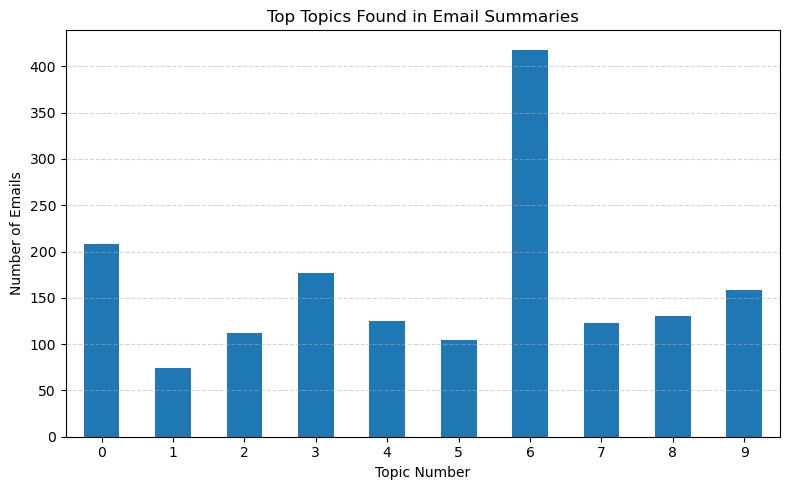

Topic #0: contact, work, patient, return, individual, status, medical, regarding, date, disability
Topic #1: plant, writer, hiring, operator, freeze, overtime, needs, new, information, contact
Topic #2: safety, records, regarding, summary, specific, location, record, contact, retention, osha
Topic #3: available, access, project, contact, specific, location, request, files, review, designated
Topic #4: contact, employee, meeting, issue, writer, location, potential, specific, time, summary
Topic #5: pre, employment, writer, drawings, manuals, changes, contact, summary, work, test
Topic #6: email, summary, writer, contact, information, concise, specific, details, sent, sensitive
Topic #7: summary, employee, contact, human, resources, regarding, relations, related, writer, work
Topic #8: writer, time, contact, meeting, period, work, status, benefits, employee, probationary
Topic #9: specific, writer, time, location, request, individual, date, timecards, certain, contact
Topic #0 → Title: "

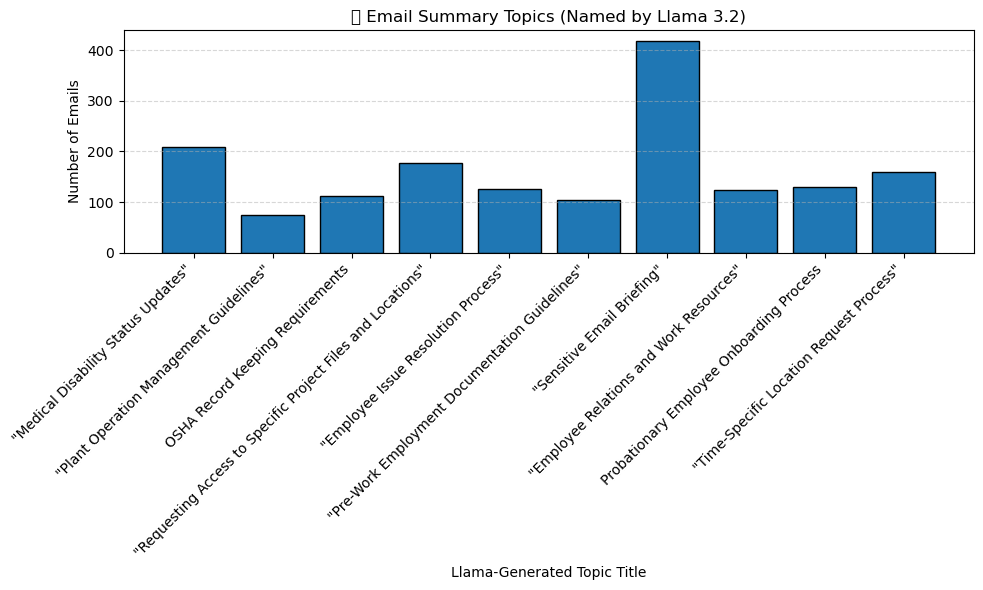

In [90]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import subprocess
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings

# Suppress warnings (e.g., SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# File path (raw string for Windows compatibility)
file_path = r"C:\Emails_Archiving\emails_parsed_rewritten_summaries.csv"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)


# Download stopwords
nltk.download("stopwords")

# Simple cleaning function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

stop_words = set(stopwords.words("english"))

# Clean email summaries instead of subject lines
df["summary_clean"] = df["email_summaries"].apply(clean_text)
df["summary_clean"] = df["summary_clean"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

# Vectorize the cleaned email summaries
vectorizer = CountVectorizer(max_df=0.9, min_df=2, stop_words="english")
doc_term_matrix = vectorizer.fit_transform(df["summary_clean"])

# Topic modeling with LDA
num_topics = 10  # Increased from 5 to 10 topics
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_topics = lda_model.fit_transform(doc_term_matrix)

# Assign dominant topic to each row
df["dominant_topic"] = np.argmax(lda_topics, axis=1)

# Count the number of rows per topic and plot a simple bar chart
topic_counts = df["dominant_topic"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
topic_counts.plot(kind="bar")
plt.title("Top Topics Found in Email Summaries")
plt.xlabel("Topic Number")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Function to display top keywords for each topic
def display_topics(model, feature_names, top_n=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features_indices = topic.argsort()[-top_n:][::-1]
        top_features = [feature_names[i] for i in top_features_indices]
        print(f"Topic #{topic_idx}: {', '.join(top_features)}")

# Get feature names from the vectorizer and display top keywords per topic
feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, feature_names, top_n=10)

# Path to Ollama and Llama model
ollama_path = r"C:\Users\terbe\AppData\Local\Programs\Ollama\ollama.exe"
model_name = "llama3.2"

# Function to generate a topic title from keywords using Llama 3.2
def generate_topic_title(keywords):
    prompt = f"""
You are an expert at topic modeling and naming. Based on the following list of keywords extracted from a topic model, provide a short, clear, and descriptive title for the topic. Do not include any explanations—just return the title.

Keywords: {', '.join(keywords)}
"""
    try:
        result = subprocess.run(
            [ollama_path, "run", model_name, "--", prompt],
            input=prompt,
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace"
        )
        if result.returncode != 0:
            print("Error generating topic title:", result.stderr)
            return ""
        return result.stdout.strip()
    except Exception as e:
        print(f"An error occurred during topic title generation: {e}")
        return ""

# Generate Llama topic titles and store them in a dictionary
topic_titles = {}
for topic_idx, topic in enumerate(lda_model.components_):
    top_features_indices = topic.argsort()[-10:][::-1]
    top_keywords = [feature_names[i] for i in top_features_indices]
    topic_title = generate_topic_title(top_keywords)
    topic_titles[topic_idx] = {
        "keywords": top_keywords,
        "generated_title": topic_title
    }
    print(f"Topic #{topic_idx} → Title: {topic_title}")

# Prepare a DataFrame to show Llama topic titles
topic_records = []
for idx, info in topic_titles.items():
    topic_records.append({
        "Topic Number": idx,
        "Llama Title": info["generated_title"],
        "Top Keywords": ", ".join(info["keywords"])
    })

topic_titles_df = pd.DataFrame(topic_records)

# Create a DataFrame for topic counts with Llama-generated titles
topic_counts = df["dominant_topic"].value_counts().sort_index()
topic_counts_df = topic_counts.reset_index()
topic_counts_df.columns = ["Topic", "Email_Count"]

topic_counts_df["Topic_Label"] = topic_counts_df["Topic"].apply(
    lambda x: topic_titles.get(x, {}).get("generated_title", f"Topic #{x}")
)

# Plot a bar chart with Llama-generated topic titles
plt.figure(figsize=(10, 6))
plt.bar(topic_counts_df["Topic_Label"], topic_counts_df["Email_Count"], edgecolor='black')
plt.title("📬 Email Summary Topics (Named by Llama 3.2)")
plt.xlabel("Llama-Generated Topic Title")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 📊 Email Preprocessing & Summarization Pipeline Summary


## ⏱️ Performance
- **Observed Time for 10 Rows**: 347.80 seconds  
- **Average Per Row**: ~34.78 seconds  
- **Projected Sequential Runtimes**:
  - 100,000 rows → ~966 hours (~40.3 days)  
  - 1,000,000 rows → ~9,667 hours (~402.8 days)  
- **Current Bottleneck**: LLM summarization via local Ollama CLI is single-threaded and reloads the model each time  

---

## 🔚 Conclusion
The pipeline successfully structured and anonymized legacy email data for long-term archival. While PII extraction via `presidio-analyzer` was efficient, summarization using Ollama's LLM is too slow for large-scale processing without further optimization.

---

## ⚡ Optimization Opportunities
- **Parallelization**: Use `multiprocessing` or `joblib` to handle rows concurrently  
- **Persistent LLM Runtime**: Run Ollama in server mode to prevent model reloads  
- **Prompt Simplification**: Shorten prompts to reduce processing time  
- **Cloud-based Summarization**: Offload to fast APIs (e.g., OpenAI, Claude, Gemini)  
- **Incremental Caching**: Track and skip already processed rows using row ID hashing  
